In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score

from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from scipy.spatial.distance import pdist

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving seeds_dataset.txt to seeds_dataset.txt


In [ ]:
columns = [
    'Area',
    'Perimeter',
    'Compactness',
    'Kernel_Length',
    'Kernel_Width',
    'Asymmetry',
    'Groove_Length',
    'Variety'
]
df = pd.read_csv(
    'seeds_dataset.txt',
    sep='\s+',
    header=None,
    names=columns
)
df.head()

<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1104/1565540105.py:13: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',


,Area,Perimeter,Compactness,Kernel_Length,Kernel_Width,Asymmetry,Groove_Length,Variety
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [ ]:
df.shape
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Area           210 non-null    float64
 1   Perimeter      210 non-null    float64
 2   Compactness    210 non-null    float64
 3   Kernel_Length  210 non-null    float64
 4   Kernel_Width   210 non-null    float64
 5   Asymmetry      210 non-null    float64
 6   Groove_Length  210 non-null    float64
 7   Variety        210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB


In [ ]:
df.describe()

,Area,Perimeter,Compactness,Kernel_Length,Kernel_Width,Asymmetry,Groove_Length,Variety
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071,2.000000
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480,0.818448
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000,1.000000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000,1.000000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000,2.000000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000,3.000000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000,3.000000


In [ ]:
df.isnull().sum()

,0
Area,0
Perimeter,0
Compactness,0
Kernel_Length,0
Kernel_Width,0
Asymmetry,0
Groove_Length,0
Variety,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Variety'].value_counts()

,count
Variety,
1,70
2,70
3,70


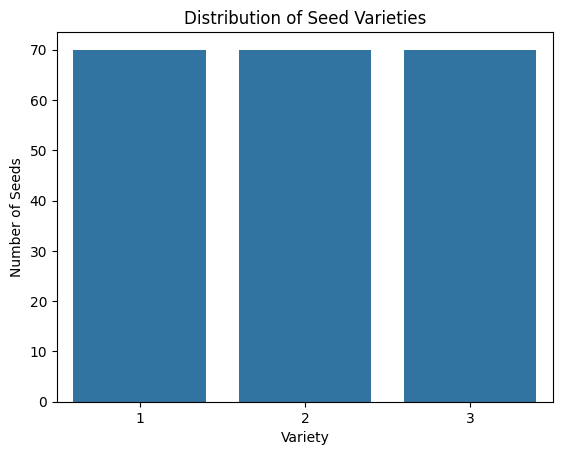

In [ ]:
sns.countplot(x='Variety', data=df)
plt.title("Distribution of Seed Varieties")
plt.xlabel("Variety")
plt.ylabel("Number of Seeds")
plt.show()

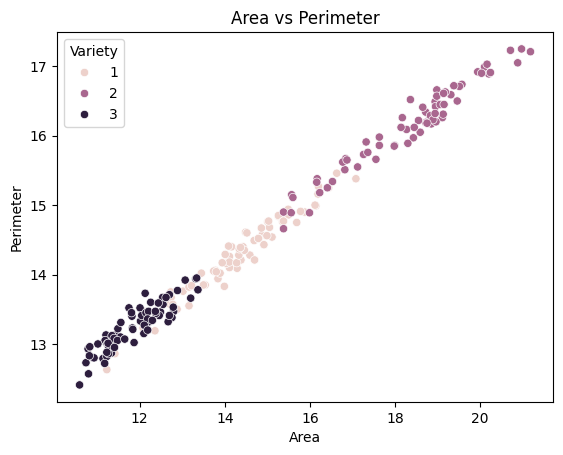

In [ ]:
sns.scatterplot(
    data=df,
    x='Area',
    y='Perimeter',
    hue='Variety'
)
plt.title("Area vs Perimeter")
plt.xlabel("Area")
plt.ylabel("Perimeter")
plt.show()

In [ ]:
X = df.iloc[:, :-1]
y = df['Variety']

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
ward_linkage = linkage(
    X_scaled,
    method='ward'
)

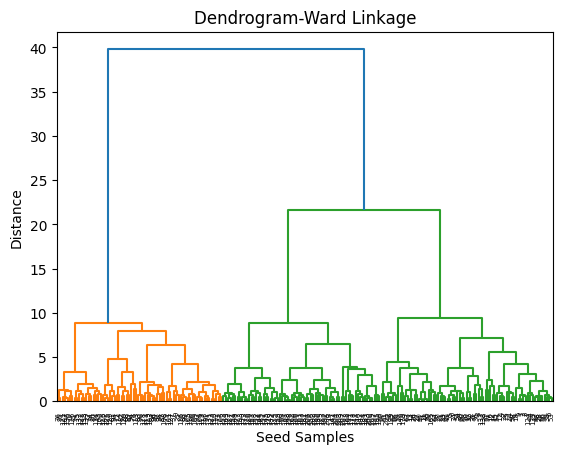

In [ ]:
dendrogram(ward_linkage)
plt.title("Dendrogram-Ward Linkage")
plt.xlabel("Seed Samples")
plt.ylabel("Distance")
plt.show()

In [ ]:
complete_linkage = linkage(
    X_scaled,
    method='complete'
)

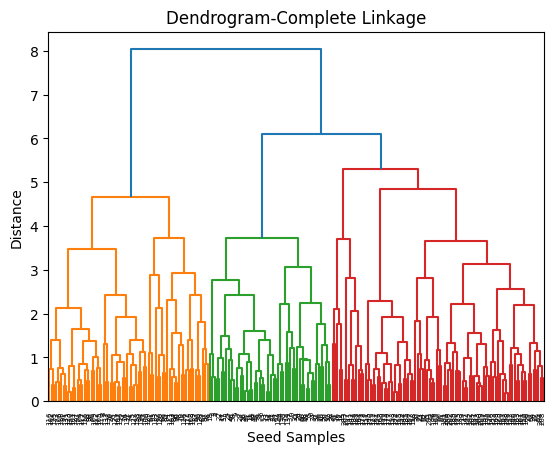

In [ ]:
dendrogram(complete_linkage)
plt.title("Dendrogram-Complete Linkage")
plt.xlabel("Seed Samples")
plt.ylabel("Distance")
plt.show()

In [ ]:
ward_model = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)
ward_labels = ward_model.fit_predict(X_scaled)

In [ ]:
complete_model = AgglomerativeClustering(
    n_clusters=3,
    linkage='complete'
)
complete_labels = complete_model.fit_predict(X_scaled)

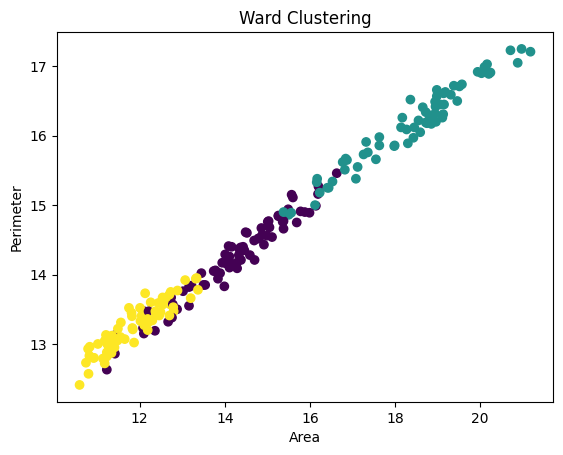

In [ ]:
plt.scatter(
    X['Area'],
    X['Perimeter'],
    c=ward_labels
)
plt.xlabel("Area")
plt.ylabel("Perimeter")
plt.title("Ward Clustering")
plt.show()

In [ ]:
ward_silhouette = silhouette_score(
    X_scaled,
    ward_labels
)
complete_silhouette = silhouette_score(
    X_scaled,
    complete_labels
)
print("Ward Silhouette Score:", ward_silhouette)
print("Complete Silhouette Score:", complete_silhouette)

Ward Silhouette Score: 0.3926339709101015
Complete Silhouette Score: 0.35019845816108097


In [ ]:
ward_ari = adjusted_rand_score(
    y,
    ward_labels
)
complete_ari = adjusted_rand_score(
    y,
    complete_labels
)
print("Ward ARI:", ward_ari)
print("Complete ARI:", complete_ari)

Ward ARI: 0.796998283593012
Complete ARI: 0.6862625605760001


In [ ]:
ward_cophenetic, _ = cophenet(
    ward_linkage,
    pdist(X_scaled)
)
complete_cophenetic, _ = cophenet(
    complete_linkage,
    pdist(X_scaled)
)
print("Ward Cophenetic Correlation:", ward_cophenetic)
print("Complete Cophenetic Correlation:", complete_cophenetic)

Ward Cophenetic Correlation: 0.7285528540866004
Complete Cophenetic Correlation: 0.7129628799252149


In [ ]:
results = []
for method in ['ward', 'complete']:
    for k in [2, 3, 4, 5]:
        model = AgglomerativeClustering(
            n_clusters=k,
            linkage=method
        )
        labels = model.fit_predict(X_scaled)
        silhouette = silhouette_score(
            X_scaled,
            labels
        )
        ari = adjusted_rand_score(
            y,
            labels
        )
        results.append([
            method,
            k,
            silhouette,
            ari
        ])
results_df = pd.DataFrame(
    results,
    columns=[
        'Linkage',
        'Clusters',
        'Silhouette Score',
        'ARI'
    ]
)
results_df

,Linkage,Clusters,Silhouette Score,ARI
0,ward,2,0.461297,0.476203
1,ward,3,0.392634,0.796998
2,ward,4,0.300576,0.730928
3,ward,5,0.274639,0.615925
4,complete,2,0.451995,0.488254
5,complete,3,0.350198,0.686263
6,complete,4,0.314857,0.654853
7,complete,5,0.293720,0.582087
